In [63]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
matplotlib.rcParams["ps.useafm"] = True
matplotlib.rcParams["pdf.use14corefonts"] = True
import seaborn as sns
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
%matplotlib inline
import pandas as pd
plt.rcParams['font.size'] = 8

In [65]:
df = pd.read_csv('/rawdata/fig2_rawdata.csv')
df.columns=['causal', 'positive', 'A', 'B', 'C', 'D', 'E', 'F']
df = df[['causal', 'positive', 'A', 'B', 'C', 'F']]
df = df.loc[df['positive']>=0.5]
df.columns=['Causal proportion', 'Effect direction mixture', 'Unmodified', 'Unmodified w/ GReX covariate', 'PrediXSKAT', 'PrediXSKAT w/ GReX covariate']
noefp = df.melt(id_vars=['Causal proportion', 'Effect direction mixture'], var_name='kernel', value_name='pval')

In [3]:
def power(x, alpha):
    pvals = x['pval']
    type2_error = len([x for x in pvals if (x) > alpha]) / len(pvals)
    power = 1 - type2_error
    return power

In [4]:
noef_power1 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.05).reset_index()
noef_power2 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.005).reset_index()
noef_power3 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.0005).reset_index()

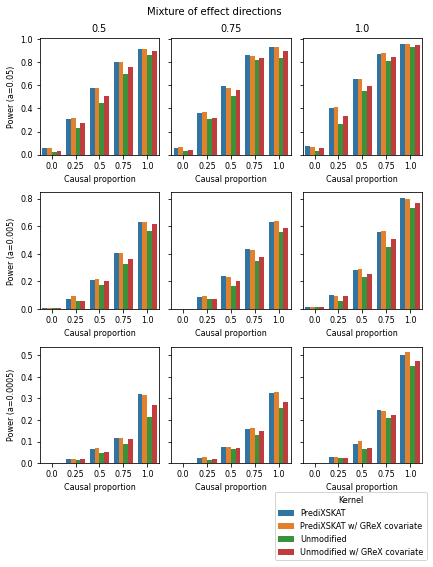

In [62]:
dataframes = [noef_power1, noef_power2, noef_power3]
col_vals = noef_power1['Effect direction mixture'].unique() 
n_rows, n_cols = len(dataframes), len(col_vals)
row_labels = ['Power (a=0.05)', 'Power (a=0.005)', 'Power (a=0.0005)'] 
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6, 7),
    sharey='row')

for row, df in enumerate(dataframes):
    for col, col_val in enumerate(col_vals):
        ax = axes[row, col]
        subset = df[df['Effect direction mixture'] == col_val]
        sns.barplot(data=subset, x='Causal proportion', y=0, hue='kernel', ax=ax)
        if row == 0:
            ax.set_title(col_val)
        ax.set_ylabel(row_labels[row] if col == 0 else '')
        ax.get_legend().remove()

fig.suptitle('Mixture of effect directions', fontsize=10)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Kernel', loc='lower right', bbox_to_anchor=(1, -0.125))

plt.tight_layout()
fig.savefig("fig2.pdf", format="pdf", bbox_inches="tight");

In [78]:
noef1 = df.copy()
#noef1['PrediXSKAT'] = noef1['PrediXSKAT']*0.3
noefp = noef1.melt(id_vars=['Causal proportion', 'Effect direction mixture'], var_name='kernel', value_name='pval')
pvasls = noefp.loc[(noefp['Causal proportion']==1)& (noefp['Effect direction mixture']==1)
                  & ((noefp['kernel']=='Unmodified') | (noefp['kernel']=='PrediXSKAT'))]
pvasls['-log10p'] = -1*np.log10(pvasls['pval'])

/tmp/job.3399021.pioneer/ipykernel_2090922/1365976338.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pvasls['-log10p'] = -1*np.log10(pvasls['pval'])


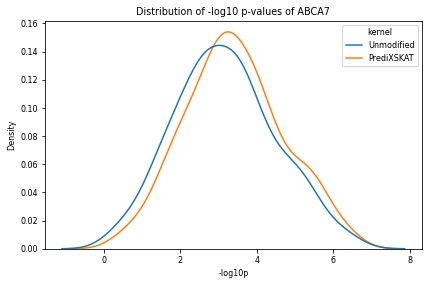

In [81]:
plt.subplots(figsize=(6, 4))
sns.kdeplot(pvasls, x='-log10p', hue='kernel')
plt.title('Distribution of -log10 p-values of ABCA7')
plt.tight_layout()
plt.savefig("fig7.pdf", format="pdf", bbox_inches="tight");